## ML2_Supervised learning

## 1. Основная информация.

## 1.a Аналитическое решение для линейной регрессии

Для линейной регрессии с квадратичной функцией потерь аналитическое решение имеет вид:

$$
\theta = (X^\top X)^{-1} X^\top y
$$

На практике при вырожденности матрицы $X^\top X$ используют псевдообратную матрицу.

## 1.b Функция потерь с регуляризацией

При добавлении регуляризации задача принимает вид:

$$
\min_{\theta} \sum_{i=1}^{N} L(f(x_i, \theta), y_i) + \lambda R(\theta)
$$

где $R(\theta)$ — штраф на параметры модели.

## 1.c L1-регуляризация

L1-регуляризация задаётся как:

$$
R(\theta) = \|\theta\|_1 = \sum_{j=1}^{d} |\theta_j|
$$

Она способствует обнулению слабых коэффициентов и может использоваться для отбора признаков.

## 1.d Моделирование нелинейных зависимостей

Нелинейные зависимости можно учитывать с помощью:
- полиномиальных признаков;
- нелинейных преобразований, таких как $\log$, $\exp$, $\sqrt{x}$, $\sin(x)$;
- новых признаков, построенных как комбинации исходных.

## 2. Подготовка данных.

In [51]:
import sys
print(sys.executable)

/Users/cleganeb/Desktop/ML2_Supervised_learning.ID_1254799-1/.venv/bin/python


In [52]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#from sklearn.datasets import load_boston
from sklearn.preprocessing import PolynomialFeatures
from scipy.stats import skew
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import json
from collections import Counter
import re
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from tabulate import tabulate
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [53]:
data = pd.read_json('/Users/cleganeb/Desktop/ML2_Supervised_learning.ID_1254799-1/src/data/train.json')
display(data.head())

rows, columns = data.shape
print(f"Количество строк: {rows}, количество столбцов: {columns}")

column_names = list(data.columns)
print("Столбцы:", column_names)
print("Целевой столбец:", 'price')


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


Количество строк: 49352, количество столбцов: 15
Столбцы: ['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']
Целевой столбец: price


## 3. Введение в анализ данных.

In [54]:
def normalize_feature(feature):
    if not feature:
        return ""
    
    # 1. Очистка: оставляем буквы, цифры, дефисы и пробелы
    cleaned = ''.join(char for char in feature if char.isalnum() or char in ('-', ' ')).strip()
    
    # 2. Разделяем по пробелам, чтобы обработать каждое "слово" (например, "pre-war")
    words = cleaned.split()
    
    normalized_words = []
    for word in words:
        # Если внутри слова есть дефис (как в Pre-War)
        if '-' in word:
            # Капитализируем каждую подчасть дефиса: pre-war -> Pre-War
            sub_parts = [p.capitalize() for p in word.split('-')]
            normalized_words.append('-'.join(sub_parts))
        else:
            # Обычное слово: wifi -> Wifi
            normalized_words.append(word.capitalize())
            
    # 3. Соединяем (без пробелов, как в PascalCase, но с дефисами внутри слов)
    return ''.join(normalized_words)

# Чистка и нормализация данных
data['clean_features'] = data['features'].apply(
    lambda x: ''.join(json.dumps(x).replace('[', '').replace(']', '').replace("'", "").replace('"', '')).strip().lower())

# Сбор всех признаков
all_values = []
for index, row in data.iterrows():
    features = row['clean_features'].split(',')
    clean_features = [normalize_feature(feat.strip()) for feat in features]  # нормализация признаков
    all_values.extend(clean_features)

# Исключаем пустые значения
all_values = [val for val in all_values if val != '']

# Подсчет уникальных значений
unique_values = set(all_values)
print(f"Уникальных значений: {len(unique_values)}")

Уникальных значений: 1260


In [55]:
counter = Counter(all_values)
# top_20_features = counter.most_common(20)

top_20_features = [feature for feature, _ in counter.most_common(20)]

# Выводим результат через запятую
result_string = ', '.join(top_20_features)
print(result_string)

Elevator, HardwoodFloors, CatsAllowed, DogsAllowed, Doorman, Dishwasher, LaundryInBuilding, NoFee, FitnessCenter, LaundryInUnit, Pre-War, RoofDeck, OutdoorSpace, DiningRoom, HighSpeedInternet, Balcony, SwimmingPool, NewConstruction, Terrace, Exclusive


In [56]:
for feature_name in top_20_features:
    # Мы нормализуем текущий список в строке и проверяем наличие в нем feature_name
    data[feature_name] = data['features'].apply(
        lambda x: 1 if feature_name in [normalize_feature(f) for f in x] else 0
    )

# Проверка результата
display(data.head())
print(data[top_20_features].sum())

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,Pre-War,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,NewConstruction,Terrace,Exclusive
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,...,1,0,0,1,0,0,0,0,0,0
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,...,0,0,0,0,0,0,0,0,0,0
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,...,0,0,0,0,0,0,0,0,0,0


Elevator             26272
HardwoodFloors       23559
CatsAllowed          23540
DogsAllowed          22035
Doorman              20966
Dishwasher           20804
LaundryInBuilding    18638
NoFee                18065
FitnessCenter        13252
LaundryInUnit         9345
Pre-War               9149
RoofDeck              6555
OutdoorSpace          5270
DiningRoom            5150
HighSpeedInternet     4299
Balcony               3058
SwimmingPool          2730
NewConstruction       2608
Terrace               2313
Exclusive             2167
dtype: int64


In [57]:


# 1. Формируем финальный список имен столбцов
feature_list = ['price', 'bathrooms', 'bedrooms'] + top_20_features

# 2. Создаем новую таблицу, которая содержит ТОЛЬКО эти 22 колонки
# .copy() гарантирует, что мы работаем с новым объектом, а не ссылкой
data_filtered = data[feature_list].copy()

# 3. Проверка результата
print(f"Формат новой таблицы: {data_filtered.shape}") # Должно быть (N, 22)
print(f"Список оставшихся колонок: {data_filtered.columns.tolist()}")

# Вывод первых строк очищенной таблицы
display(data_filtered.head())



Формат новой таблицы: (49352, 23)
Список оставшихся колонок: ['price', 'bathrooms', 'bedrooms', 'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'LaundryInBuilding', 'NoFee', 'FitnessCenter', 'LaundryInUnit', 'Pre-War', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'NewConstruction', 'Terrace', 'Exclusive']


,price,bathrooms,bedrooms,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,LaundryInBuilding,...,Pre-War,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,NewConstruction,Terrace,Exclusive
4,2400,1.0,1,0,1,1,1,0,1,1,...,1,0,0,1,0,0,0,0,0,0
6,3800,1.0,2,1,1,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
9,3495,1.0,2,1,1,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
10,3000,1.5,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,2795,1.0,0,1,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [58]:
q99 = data_filtered['price'].quantile(0.99)
q01 = data_filtered['price'].quantile(0.01)

data_filtered.drop(data_filtered[data_filtered['price']>q99].index,inplace=True)
data_filtered.drop(data_filtered[data_filtered['price']<q01].index,inplace=True)


X = data_filtered.drop('price', axis=1)  # Признаки
y = data_filtered['price']               # Целевой признак

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)



print("Размер обучающей выборки:", len(X_train))
print("Размер тестовой выборки:", len(X_test))


Размер обучающей выборки: 38703
Размер тестовой выборки: 9676


## 4. Реализация моделей - Линейная регрессия и моделей с регуляризацией — Ridge, Lasso, ElasticNet.

## Линейная регрессия с аналитическим решением. Быстро и точно решает задачу, но требует значительных ресурсов памяти и плохо масштабируется на большие наборы данных.

In [59]:
class LinearRegressionAnalytic:
    def __init__(self):
        self.weights = None
    
    def fit(self, X, y):
        # Добавляем столбец единиц для смещения (bias term)
        X_b = np.c_[np.ones((len(X), 1)), X]
        
        # Используем формулы метода наименьших квадратов
        self.weights = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    
    def predict(self, X):
        # Предсказываем новые точки
        return np.c_[np.ones((len(X), 1)), X].dot(self.weights)
    
model = LinearRegressionAnalytic()
model.fit(X_train.values, y_train.values)
predictions = model.predict(X_test.values)

print(predictions[:5])  # Первые пять предсказаний
print(model.weights)

[3468.12267085 3384.11074815 2177.44277301 3358.18895652 3273.75739776]
[ 595.14916104 1582.29361197  458.67995186  190.11811404 -128.29484045
 -108.64865059  166.25828084  637.65803694  130.35033842 -267.02426202
 -187.43189483  252.57042708  476.49429572   -6.7617784   -85.07391109
  -70.09525772  125.77799677 -208.86953624  -48.21764362   37.15303456
 -129.80355616  175.33063071   29.78420728]


## Нестохастический градиентный спуск (Batch Gradient Descent). Обеспечивает стабильную работу, медленно сходится, но даёт точные решения.

In [60]:
class LinearRegressionGradientDescent:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
    
    def _cost_function(self, X, y, weights):
        m = len(y)
        predictions = X.dot(weights)
        cost = np.sum((predictions - y)**2)/(2*m)
        return cost
    
    def gradient_descent(self, X, y):
        m = len(y)
        for epoch in range(self.epochs):
            gradients = (1/m)*X.T.dot(X.dot(self.weights)-y)
            self.weights -= self.learning_rate * gradients
            
    def fit(self, X, y):
        # Добавляем столбец единиц для смещения
        X_b = np.c_[np.ones((len(X), 1)), X]
        n_features = X_b.shape[1]
        self.weights = np.zeros(n_features)
        
        self.gradient_descent(X_b, y)
    
    def predict(self, X):
        return np.c_[np.ones((len(X), 1)), X].dot(self.weights)
    
model = LinearRegressionGradientDescent()
model.fit(X_train.values, y_train.values)
predictions = model.predict(X_test.values)

print(predictions[:5])  # Первые пять предсказаний
print(model.weights)

[3538.99137418 3360.31650361 2112.20114937 3372.85057159 3352.2560954 ]
[ 695.81509175 1416.38605763  496.55531099  239.83266585  -68.11694341
   34.40984887   61.25088779  539.223079     91.12599327 -195.33534591
 -150.04079612  226.74614598  353.68661525    8.91551785  -79.76215999
  -18.08784189   78.17421602 -140.94394485   11.08056983   44.16625971
  -46.28115671   51.67319791   44.29092629]


## Используйте стохастический градиентный спуск (SGD) с двумя основными методами — fit и predict, для поиска оптимальных весов модели. Быстрая работа даже на огромных объёмах данных, быстро сходится, но подвержен большим колебаниям на ранних этапах обучения.

In [62]:
class LinearRegressionSGD:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate  # скорость обучения
        self.epochs = epochs                # количество итераций
        self.weights = None                 # начальные веса пока неизвестны
        self.bias = None                    # смещение тоже неизвестно изначально
    
    def fit(self, X, y):
        # Приводим входные данные к нужному формату
        n_samples, n_features = X.shape
        
        # Инициализация весов случайными малыми числами и нулевого смещения
        self.weights = np.random.randn(n_features)
        self.bias = 0
    
        for _ in range(self.epochs):   # Цикл по количеству эпох
            for idx in range(n_samples):     # Обходим выборочно каждую строку набора данных
                # Вычисление текущего предсказанного значения
                predicted_y = np.dot(X[idx], self.weights) + self.bias
            
                # Разница между настоящим и предсказанным значением
                error = predicted_y - y[idx]
                
                # Обновляем веса и смещение пропорционально ошибке
                self.weights -= self.learning_rate * error * X[idx]
                self.bias -= self.learning_rate * error

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    
model = LinearRegressionSGD()
model.fit(X_train.values, y_train.values)
predictions = model.predict(X_test.values)

print(predictions[:5])  # Первые пять предсказаний
print(model.weights)


[3592.30930302 3052.5808877  2114.1989224  3184.73997328 2881.63491351]
[1520.29093803  534.79249749  305.15428335 -145.86671935 -203.69247771
  122.62219553  608.15552343  -30.27456646 -258.79009948 -245.99432165
  299.4403509   452.25370633  -26.78221298 -221.03915812  -27.83219301
  125.97152099 -273.02776478  -65.69372075    2.92848318 -148.88925277
   96.1681294   301.8274202 ]


## Сделать cтохастический градиентный спуск (SGD) детерменированным.

## Детерминированная модель — это тип модели, используемый в науке, математике и экономике, в которой исход процесса однозначно определяется заданными начальными условиями и параметрами системы. То есть, если известны начальные условия и правила поведения системы, результат всегда получается один и тот же, без случайности или неопределенности.

## Основные характеристики детерминированных моделей:

## Однозначность: Однотипные входные данные всегда приводят к одному и тому же выходу.
## Отсутствие стохастичности: Не учитывается влияние случайных факторов или вероятностных процессов.
## Предсказуемость: Возможность точно предсказывать поведение системы на основании известных правил и условий.

In [63]:
class LinearRegressionSGD:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Устанавливаем фиксированный seed для детерминированности
        np.random.seed(21)
        
        # Инициализируем веса случайными числами
        self.weights = np.random.randn(n_features)
        self.bias = 0
    
        indices = list(range(n_samples))  # Фиксированная последовательность индексов
    
        for _ in range(self.epochs):
            for idx in indices:
                # Прогнозируемое значение
                predicted_y = np.dot(X[idx], self.weights) + self.bias
            
                # Ошибка
                error = predicted_y - y[idx]
                
                # Обновляем веса и смещение
                self.weights -= self.learning_rate * error * X[idx]
                self.bias -= self.learning_rate * error

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    

model = LinearRegressionSGD()
model.fit(X_train.values, y_train.values)
predictions = model.predict(X_test.values)

print(predictions[:5])  # Первые пять предсказаний
print(model.weights)

[3592.30930302 3052.5808877  2114.1989224  3184.73997328 2881.63491351]
[1520.29093803  534.79249749  305.15428335 -145.86671935 -203.69247771
  122.62219553  608.15552343  -30.27456646 -258.79009948 -245.99432165
  299.4403509   452.25370633  -26.78221298 -221.03915812  -27.83219301
  125.97152099 -273.02776478  -65.69372075    2.92848318 -148.88925277
   96.1681294   301.8274202 ]


## Модель называется детерминированной, если при одних и тех же входных данных она выдаёт одно и то же выходное значение. То есть поведение модели строго определено и воспроизводимо.

## Примером детерминированной модели служит линейная регрессия, особенно если применяется аналитическое решение или обычная процедура градиентного спуска с заранее установленными параметрами (такими как число итераций и величина шага обучения).

## Напротив, если при одном и том же входе получаются разные результаты, модель считается стохастической. Примеры стохастичности возникают тогда, когда:

## - Используется рандомизация в начальной точке (случайные веса).
## - Данные перемешиваются перед обработкой (это часто делается в SGD).

## Детерминизация SGD

## Stokhastic Gradient Descent (SGD) сам по себе стохастичен, потому что веса начинают своё движение из случайной стартовой позиции, а обработка данных идёт последовательностью случайных элементов выборки.

## Обновим предыдущий код класса LinearRegressionSGD, сделав его полностью детерминированным:

In [64]:
class LinearRegressionSGDDeterministic:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Зафиксируем seed, чтобы начать с одинаковых весов
        np.random.seed(21)
        
        # Случайная инициализация весов
        self.weights = np.random.randn(n_features)
        self.bias = 0
        
        # Индексация записей в порядке следования
        indices = list(range(n_samples))
    
        for _ in range(self.epochs):
            for idx in indices:
                # Текущие координаты и фактические цены
                predicted_y = np.dot(X[idx], self.weights) + self.bias
                error = predicted_y - y[idx]
                
                # Обновляем веса и смещение
                self.weights -= self.learning_rate * error * X[idx]
                self.bias -= self.learning_rate * error
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

## Функция для вычисления R² (коэффициент детерминации).

Коэффициент R^2 (коэффициент детерминации)
Коэффициент R^2 показывает долю дисперсии зависимой переменной (y),
которую объясняет наша модель. Чем ближе этот показатель к единице,
тем лучше модель описывает зависимость целевой переменной от признаков.

Формула коэффициента R^2 выглядит следующим образом:

$$R^2 = 1 - \frac{\sum_{i}(y_i - \hat{y}_i)^2}{\sum_{i}(y_i - \bar{y})^2}$$

Где:
- y_i — истинное значение,
- $\hat{y}_i$ — предсказанное моделью значение,
- $\bar{y}$ — среднее всех значений y.

Алгоритм расчета:
1. Вычислить среднюю величину целевых значений ($\bar{y}$).
2. Рассчитать сумму квадратов ошибок между истинными и предсказанными значениями
   ($\sum(y_i - \hat{y}_i)^2$, называемую остаточной суммой квадратов — RSS).
3. Рассчитать общую вариацию в исходных данных
   ($\sum(y_i - \bar{y})^2$, называемую общей суммой квадратов — TSS).
4. Подставить полученные значения в формулу и вычислить R^2.

In [84]:
def compute_metrics(y_true, y_pred):
    """
    Функция для подсчета основных метрик качества
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [86]:

# Генерация одной строки для отчета
def make_row(model_name, train_y, train_preds, test_y, test_preds):
    # Подсчет метрик
    train_mae, train_rmse, train_r2 = compute_metrics(train_y, train_preds)
    test_mae, test_rmse, test_r2 = compute_metrics(test_y, test_preds)
    
    # Сбор данных в строку
    row = {
        "model": model_name,
        "train_MAE": round(train_mae, 2),
        "test_MAE": round(test_mae, 2),
        "train_RMSE": round(train_rmse, 2),
        "test_RMSE": round(test_rmse, 2),
        "train_R2": round(train_r2, 2),
        "test_R2": round(test_r2, 2)
    }
    return row

## Сделаем прогнозы с помощью разработанной модели линейной регрессии и оценим её качество, используя стандартные метрики MAE, RMSE и R². Затем сравним полученные результаты с качеством стандартной реализации линейной регрессии из библиотеки scikit-learn (LinearRegression).

In [87]:
class MyLinearRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
    
    def fit(self, X, y):
        # Добавляем единичную колонку для смещения
        X_b = np.c_[np.ones((len(X), 1)), X]
        
        # Инициализируем веса случайными значениями
        self.weights = np.random.randn(X_b.shape[1])
        
        # Градиентный спуск
        for _ in range(self.epochs):
            gradients = 2/len(X_b) * X_b.T.dot(X_b.dot(self.weights) - y)
            self.weights -= self.learning_rate * gradients
    
    def predict(self, X):
        # Добавляем единичную колонку для смещения
        X_b = np.c_[np.ones((len(X), 1)), X]
        return X_b.dot(self.weights)


# Обучение собственной модели
my_lr = MyLinearRegression()
my_lr.fit(X_train, y_train)
my_train_preds = my_lr.predict(X_train)
my_test_preds = my_lr.predict(X_test)

# Составляем отчет по собственной модели
row_custom = make_row("My Linear Regression", y_train, my_train_preds, y_test, my_test_preds)

# ----- Библиотечная реализация -----
sklearn_lr = LinearRegression()
sklearn_lr.fit(X_train, y_train)
sklearn_train_preds = sklearn_lr.predict(X_train)
sklearn_test_preds = sklearn_lr.predict(X_test)

# Составляем отчет по библиотечной модели
row_sklearn = make_row("Scikit-Learn Linear Regression", y_train, sklearn_train_preds, y_test, sklearn_test_preds)

# Объединяем отчёты в единый DataFrame
report = pd.DataFrame([row_custom, row_sklearn])

# Отображаем отчёт
display(report)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,My Linear Regression,715.85,709.79,1041.00,1027.94,0.58,0.58
1,Scikit-Learn Linear Regression,715.83,710.43,1040.17,1027.85,0.58,0.58


## Расширим базовый алгоритм линейной регрессии. Основная идея — рассмотрим методы регуляризации (Ridge, Lasso, ElasticNet), расширим целевую функцию и изучить влияние регуляризаций на качество модели.

In [88]:
class RidgeRegression:
    def __init__(self, alpha=0.1, learning_rate=0.01, epochs=20000):
        self.alpha = alpha
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
    
    def fit(self, X, y):
        X_b = np.c_[np.ones((len(X), 1)), X]
        m, n = X_b.shape
        self.weights = np.random.randn(n)
        
        for _ in range(self.epochs):
            prediction = X_b.dot(self.weights)
            errors = prediction - y
            gradients = 2/m * X_b.T.dot(errors) + 2*self.alpha * self.weights
            self.weights -= self.learning_rate * gradients
    
    def predict(self, X):
        X_b = np.c_[np.ones((len(X), 1)), X]
        return X_b.dot(self.weights)

In [89]:
class LassoRegression:
    def __init__(self, alpha=1.0, learning_rate=0.01, epochs=1000):
        self.alpha = alpha
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
    
    def soft_thresholding(self, w, threshold):
        return np.sign(w) * np.maximum(np.abs(w) - threshold, 0)
    
    def fit(self, X, y):
        X_b = np.c_[np.ones((len(X), 1)), X]
        m, n = X_b.shape
        self.weights = np.random.randn(n)
        
        for _ in range(self.epochs):
            prediction = X_b.dot(self.weights)
            errors = prediction - y
            gradients = 2/m * X_b.T.dot(errors)
            self.weights = self.soft_thresholding(self.weights - self.learning_rate*gradients, self.alpha)
    
    def predict(self, X):
        X_b = np.c_[np.ones((len(X), 1)), X]
        return X_b.dot(self.weights)

In [90]:
class ElasticNetRegression:
    def __init__(self, alpha=1.0, l1_ratio=0.5, learning_rate=0.01, epochs=1000):
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
    
    def soft_thresholding(self, w, threshold):
        return np.sign(w) * np.maximum(np.abs(w) - threshold, 0)
    
    def fit(self, X, y):
        X_b = np.c_[np.ones((len(X), 1)), X]
        m, n = X_b.shape
        self.weights = np.random.randn(n)
        
        for _ in range(self.epochs):
            prediction = X_b.dot(self.weights)
            errors = prediction - y
            gradients = 2/m * X_b.T.dot(errors)
            l1_penalty = self.alpha * self.l1_ratio
            l2_penalty = self.alpha * (1 - self.l1_ratio)
            self.weights = self.soft_thresholding(self.weights - self.learning_rate*(gradients + l2_penalty*self.weights), l1_penalty)
    
    def predict(self, X):
        X_b = np.c_[np.ones((len(X), 1)), X]
        return X_b.dot(self.weights)

In [91]:
# Создаем объекты для собственных реализаций
ridge_regression = RidgeRegression()
lasso_regression = LassoRegression()
elastic_net_regression = ElasticNetRegression()

# Обучаем собственные модели
ridge_regression.fit(X_train, y_train)
lasso_regression.fit(X_train, y_train)
elastic_net_regression.fit(X_train, y_train)

# Прогнозируем значения на тестовой выборке
ridge_preds_train = ridge_regression.predict(X_train)
ridge_preds_test = ridge_regression.predict(X_test)

lasso_preds_train = lasso_regression.predict(X_train)
lasso_preds_test = lasso_regression.predict(X_test)

elasticnet_preds_train = elastic_net_regression.predict(X_train)
elasticnet_preds_test = elastic_net_regression.predict(X_test)

# Создаем объекты для библиотечных реализаций
library_models = [
    ('Ridge', Ridge(alpha=1.0)),
    ('Lasso', Lasso(alpha=1.0, max_iter=20000)),
    ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=20000))
]

# Обучаем библиотечные модели и получаем прогнозы
library_results = []
for name, model in library_models:
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    library_results.append(make_row(name, y_train, train_preds, y_test, test_preds))

# Создаем отчёт для собственных реализаций
own_results = [
    make_row('Ridge own', y_train, ridge_preds_train, y_test, ridge_preds_test),
    make_row('Lasso own', y_train, lasso_preds_train, y_test, lasso_preds_test),
    make_row('ElasticNet own', y_train, elasticnet_preds_train, y_test, elasticnet_preds_test)
]

# Объединяем результаты в единый DataFrame
final_report = pd.concat([
    pd.DataFrame(library_results),
    pd.DataFrame(own_results)
])

# Выводим отчёт
display(final_report)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Ridge,715.83,710.43,1040.17,1027.85,0.58,0.58
1,Lasso,715.39,709.99,1040.36,1027.79,0.58,0.58
2,ElasticNet,811.05,797.18,1194.64,1178.36,0.44,0.45
0,Ridge own,721.13,712.11,1064.79,1046.89,0.56,0.57
1,Lasso own,727.06,718.96,1067.83,1046.95,0.55,0.57
2,ElasticNet own,749.28,738.81,1113.13,1092.70,0.52,0.53


## Общий вывод всех моделей.

In [92]:
# Список всех моделей (собственные и библиотечные)
all_models = [
    ("Standard LinearRegression", LinearRegression()),
    ("Ridge (biblioteka)", Ridge(alpha=1.0)),
    ("Lasso (biblioteka)", Lasso(alpha=1.0)),
    ("ElasticNet (biblioteka)", ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ("My LinearRegression", MyLinearRegression()),  # Собственная реализация
    ("My Ridge", RidgeRegression()),               # Собственная реализация
    ("My Lasso", LassoRegression()),               # Собственная реализация
    ("My ElasticNet", ElasticNetRegression())      # Собственная реализация
]

# Основной цикл обучения и формирования отчёта
reports = []
for name, model in all_models:
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    reports.append(make_row(name, y_train, train_preds, y_test, test_preds))

# Создаём итоговую таблицу
final_report = pd.DataFrame(reports)

# Выводим итоговую таблицу
display(final_report)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Standard LinearRegression,715.83,710.43,1040.17,1027.85,0.58,0.58
1,Ridge (biblioteka),715.83,710.43,1040.17,1027.85,0.58,0.58
2,Lasso (biblioteka),715.39,709.99,1040.36,1027.79,0.58,0.58
3,ElasticNet (biblioteka),719.92,711.24,1053.81,1038.70,0.57,0.58
4,My LinearRegression,715.85,709.78,1040.99,1027.93,0.58,0.58
5,My Ridge,721.13,712.11,1064.79,1046.89,0.56,0.57
6,My Lasso,727.06,718.96,1067.83,1046.95,0.55,0.57
7,My ElasticNet,749.28,738.81,1113.13,1092.70,0.52,0.53


In [93]:
# Определение лучшей модели по каждой метрике
best_model_by_mae = final_report.loc[final_report["test_MAE"].argmin(), "model"]
best_model_by_rmse = final_report.loc[final_report["test_RMSE"].argmin(), "model"]
best_model_by_r2 = final_report.loc[final_report["test_R2"].argmax(), "model"]

# Вывод наименований лучших моделей
print("Лучшая модель по MAE (средняя абсолютная ошибка):", best_model_by_mae)
print("Лучшая модель по RMSE (корень из средней квадратичной ошибки):", best_model_by_rmse)
print("Лучшая модель по R² (коэффициент детерминации):", best_model_by_r2)

# Критерий: наименьшее среднее значение MAE и RMSE на тестовой выборке
best_overall_model_idx = (
    final_report[["test_MAE", "test_RMSE"]].mean(axis=1).argmin()
)

# Лучшая модель
best_overall_model = final_report.loc[best_overall_model_idx, "model"]

# Вывод лучшей модели
print("Лучшая общая модель (баланс MAE и RMSE):", best_overall_model)

Лучшая модель по MAE (средняя абсолютная ошибка): My LinearRegression
Лучшая модель по RMSE (корень из средней квадратичной ошибки): Lasso (biblioteka)
Лучшая модель по R² (коэффициент детерминации): Standard LinearRegression
Лучшая общая модель (баланс MAE и RMSE): My LinearRegression


## 5. Нормализация признаков.

Нормализация признаков необходима во многих случаях, особенно когда разные признаки имеют сильно различающиеся масштабы. Например:

- Задача классификации изображений: пиксели изображений часто лежат в диапазоне $[0, 255]$ или $[0, 1]$. Без нормализации, алгоритм может неверно трактовать интенсивность цвета как важное свойство объекта.
- KNN-классификация (k-Nearest Neighbors) с евклидовым расстоянием: признак "возраст" в годах и "зарплата" в тысячах рублей будут иметь разное влияние на классификацию из-за разного масштаба.
- Оптимизационные алгоритмы типа градиентного спуска: оптимизаторы требуют небольших шагов изменения параметров, иначе обучение станет нестабильным или застрянет в локальных минимумах.


Однако бывают случаи, когда нормализация необязательна или даже нежелательна:

- Деревья принятия решений (Decision Tree): сами по себе деревья нечувствительны к масштабу признаков, поскольку используют пороговые условия для разделения узлов.
- Метрики точности оценивания качества классификатора (precision, recall, F1-score): здесь нормализация абсолютно неуместна.

### Мин-Макс Масштабирование (MinMaxScaler)
Нормализует данные в указанный диапазон ($[a,b]$):
$$
x'_{ij} = \frac{(x_{ij}-x^{\text{min}}_j)}{x^{\text{max}}_j-x^{\text{min}}_j}\times(b-a)+a
$$
где:
- $x_{ij}$ — значение $i$-го примера по $j$-му признаку,
- $x^{\text{min}}$ и $x^{\text{max}}$ — минимальные и максимальные значения по каждому признаку,
- $(a,b)$ — целевой диапазон (чаще всего $[0,1]$).

### Стандардизация (StandardScaler)
Приводит распределение каждого признака к нормальному распределению с нулевым средним и единичным стандартным отклонением:
$$
z_j=\frac{x_{ij}-\mu_j}{\sigma_j}
$$
где:
- $\mu_j$ — среднее значение $j$-го признака,
- $\sigma_j$ — стандартное отклонение $j$-го признака.


## Функции MinMaxScaler.

In [94]:
class MyMinMaxScaler:
    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range
    
    def fit(self, X):
        """Вычисляет min и max для каждого признака"""
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)
        
    def transform(self, X):
        """Преобразование данных с помощью MinMaxScaler"""
        range_min, range_max = self.feature_range
        scaled_X = ((X - self.min_) / (self.max_ - self.min_)) * (range_max - range_min) + range_min
        return scaled_X
    
    def fit_transform(self, X):
        """Подгонка и последующее преобразование"""
        self.fit(X)
        return self.transform(X)

## Cравним нашу реализацию с реализацией MinMaxScaler из библиотеки scikit-learn.

In [95]:
# Собственная реализация
my_scaler = MyMinMaxScaler(feature_range=(0, 1))
scaled_data_my = my_scaler.fit_transform(X)

# Стандартная реализация
scaler_sklearn = MinMaxScaler(feature_range=(0, 1))
scaled_data_sklearn = scaler_sklearn.fit_transform(X)

# Проверка совпадений
assert np.allclose(scaled_data_my, scaled_data_sklearn), "Данные различаются!"

## Функции StandardScaler.

In [96]:
class MyStandardScaler:
    def fit(self, X):
        """Вычисляет среднее и стандартное отклонение для каждого признака"""
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0, ddof=0)  # Используйте несмещённое стандартное отклонение
    
    def transform(self, X):
        """Стандартизация данных"""
        standardized_X = (X - self.mean_) / self.std_
        return standardized_X
    
    def fit_transform(self, X):
        """Подгонка и последующее преобразование"""
        self.fit(X)
        return self.transform(X)

## Cравним нашу реализацию с реализацией StandardScaler из библиотеки scikit-learn.

In [97]:
std_scaler_custom = MyStandardScaler()
standardized_data_custom = std_scaler_custom.fit_transform(X)

# Примените версию из sklearn
std_scaler_sklearn = StandardScaler()
standardized_data_sklearn = std_scaler_sklearn.fit_transform(X)

# Более слабое условие проверки
assert np.allclose(standardized_data_custom, standardized_data_sklearn, atol=1e-6), "Данные различаются!"

## 6. Обучим пользовательские модели и модели sklearn на нормализованных данных.

In [98]:
# Список для сохранения результатов
scaled_rows = []

# Инициализация объектов нормализации
minmax_scaler = MinMaxScaler()
std_scaler = StandardScaler()

# Нормализация данных
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

# Модели с MinMaxScaler
models = {
    "Linear MinMaxScaler": LinearRegression(),
    "Ridge MinMaxScaler": Ridge(),
    "Lasso MinMaxScaler": Lasso(max_iter=20000),
    "ElasticNet MinMaxScaler": ElasticNet(alpha=0.001, max_iter=20000),
}

for name, model in models.items():
    model.fit(X_train_minmax, y_train)
    scaled_rows.append(
        make_row(name, y_train, model.predict(X_train_minmax), y_test, model.predict(X_test_minmax))
    )

# Модели с StandardScaler
models = {
    "Linear StandardScaler": LinearRegression(),
    "Ridge StandardScaler": Ridge(),
    "Lasso StandardScaler": Lasso(max_iter=20000),
    "ElasticNet StandardScaler": ElasticNet(max_iter=20000),
}

for name, model in models.items():
    model.fit(X_train_std, y_train)
    scaled_rows.append(
        make_row(name, y_train, model.predict(X_train_std), y_test, model.predict(X_test_std))
    )

# Создаем итоговую таблицу
scaled_df = pd.DataFrame(scaled_rows)

# Выводим результат
display(scaled_df)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Linear MinMaxScaler,715.83,710.43,1040.17,1027.85,0.58,0.58
1,Ridge MinMaxScaler,715.95,710.38,1040.22,1027.91,0.58,0.58
2,Lasso MinMaxScaler,715.72,709.94,1040.59,1028.01,0.58,0.58
3,ElasticNet MinMaxScaler,723.23,715.86,1050.87,1039.07,0.57,0.58
4,Linear StandardScaler,715.83,710.43,1040.17,1027.85,0.58,0.58
5,Ridge StandardScaler,715.83,710.43,1040.17,1027.85,0.58,0.58
6,Lasso StandardScaler,715.63,710.19,1040.20,1027.74,0.58,0.58
7,ElasticNet StandardScaler,745.90,734.88,1085.06,1068.86,0.54,0.55


## 7. Рассмотрим модели с избыточной подготовкой.

In [140]:
X = data_filtered[['bathrooms', 'bedrooms']]
y = data_filtered['price']

# Полиномиальное преобразование (степень снижаем до 10)
poly_features = PolynomialFeatures(degree=15, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Разделение на обучающую и тестовую выборки
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=21)

# Определение моделей
models = {
    'Linear Poly': LinearRegression(),
    'Ridge Poly': Ridge(alpha=100.0, max_iter=1000),
    'Lasso Poly': Lasso(alpha=0.001, max_iter=5000, tol=1e-3),
    'ElasticNet Poly': ElasticNet(alpha=0.001, l1_ratio=0.7, max_iter=5000, tol=1e-3)
}

# Сбор результатов
poly_rows = []
for name, model in models.items():
    model.fit(X_train_poly, y_train)
    train_preds = model.predict(X_train_poly)
    test_preds = model.predict(X_test_poly)
    
    # Добавляем строку с объединёнными характеристиками train и test
    poly_rows.append(make_row(name, y_train, train_preds, y_test, test_preds))

# Создание итоговой таблицы
poly_df = pd.DataFrame(poly_rows)

# Отображение результатов
display(poly_df)


/Users/cleganeb/Desktop/ML2_Supervised_learning.ID_1254799-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.291e+10, tolerance: 9.889e+07
  model = cd_fast.enet_coordinate_descent(
/Users/cleganeb/Desktop/ML2_Supervised_learning.ID_1254799-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.293e+10, tolerance: 9.889e+07
  model = cd_fast.enet_coordinate_descent(


,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Linear Poly,785.04,1203.35,1103.47,41228.98,0.52,-667.70
1,Ridge Poly,756.54,2958.37,1079.03,216900.50,0.54,-18506.38
2,Lasso Poly,761.74,758.99,1087.98,1081.34,0.54,0.54
3,ElasticNet Poly,761.53,758.79,1087.93,1081.19,0.54,0.54


## Выбор лучшего параметра регулизации α.


In [143]:
alphas = [0.01, 0.1, 1, 10, 100, 105, 115, 118, 120]
best_alpha = None
best_r2 = -float("inf")

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)
    y_pred_test = model.predict(X_test_poly)
    current_r2 = r2_score(y_test, y_pred_test)
    
    if current_r2 > best_r2:
        best_r2 = current_r2
        best_alpha = alpha

print(f"Лучшая альфа: {best_alpha}, лучший R²: {best_r2:.2f}")

Лучшая альфа: 120, лучший R²: -13369.41


## 8. Нативные модели.

In [145]:
# Данные
X = data_filtered[['bathrooms', 'bedrooms']]
y = data_filtered['price']

# Генерация фиктивных прогнозов для тренировок (все равно оценки отсутствуют)
mean_tr = np.full(len(y_train), y_train.mean())
mean_te = np.full(len(y_test), y_train.mean())

med_tr = np.full(len(y_train), np.median(y_train))
med_te = np.full(len(y_test), np.median(y_train))

# Генерируем отчеты, включая фиктивные значения для training
native_rows = [
    make_row("Naive mean", y_train, mean_tr, y_test, mean_te),
    make_row("Naive median", y_train, med_tr, y_test, med_te)
]

# Таблица результатов
naive_df = pd.DataFrame(native_rows)

# Вывод итоговой таблицы
display(naive_df)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Naive mean,1140.45,1136.62,1598.46,1594.39,0.00,-0.00
1,Naive median,1087.46,1081.22,1645.46,1639.34,-0.06,-0.06


## 9. Сравним результаты.

## Вывод общих таблиц

In [146]:
all_res = pd.concat([final_report, scaled_df, poly_df, naive_df], ignore_index=True)

# Строим итоговые таблицы для каждой метрики
result_MAE = all_res[["model", "train_MAE", "test_MAE"]].rename(columns={
    "train_MAE": "train",
    "test_MAE": "test"
}).sort_values(by="model").reset_index(drop=True)

result_RMSE = all_res[["model", "train_RMSE", "test_RMSE"]].rename(columns={
    "train_RMSE": "train",
    "test_RMSE": "test"
}).sort_values(by="model").reset_index(drop=True)

result_R2 = all_res[["model", "train_R2", "test_R2"]].rename(columns={
    "train_R2": "train",
    "test_R2": "test"
}).sort_values(by="model").reset_index(drop=True)

# Проверка уникальности моделей
assert result_MAE["model"].duplicated().sum() == 0
assert result_RMSE["model"].duplicated().sum() == 0
assert result_R2["model"].duplicated().sum() == 0

# # Удаляем неверные названия моделей (если вдруг остались опечатки)
# assert "Ridre default" not in set(result_RMSE["model"])  # Нет такого имени
# assert "Ridge default" in set(result_RMSE["model"])  # Есть такое имя

# Выводим итоговые таблицы
print("=== result_MAE ===")
display(result_MAE)

print("=== result_RMSE ===")
display(result_RMSE)

print("=== result_R2 ===")
display(result_R2)

# Найдем лучшие модели по каждой метрике
best_mae = result_MAE.sort_values(by='test').iloc[0].to_dict()
best_rmse = result_RMSE.sort_values(by='test').iloc[0].to_dict()
best_r2 = result_R2.sort_values(by='test', ascending=False).iloc[0].to_dict()

# Выведем лучшие модели
print("Best test MAE:", best_mae)
print("Best test RMSE:", best_rmse)
print("Best test R2:", best_r2)

=== result_MAE ===


,model,train,test
0,ElasticNet (biblioteka),719.92,711.24
1,ElasticNet MinMaxScaler,723.23,715.86
2,ElasticNet Poly,761.53,758.79
3,ElasticNet StandardScaler,745.90,734.88
4,Lasso (biblioteka),715.39,709.99
5,Lasso MinMaxScaler,715.72,709.94
6,Lasso Poly,761.74,758.99
7,Lasso StandardScaler,715.63,710.19
8,Linear MinMaxScaler,715.83,710.43
9,Linear Poly,785.04,1203.35


=== result_RMSE ===


,model,train,test
0,ElasticNet (biblioteka),1053.81,1038.70
1,ElasticNet MinMaxScaler,1050.87,1039.07
2,ElasticNet Poly,1087.93,1081.19
3,ElasticNet StandardScaler,1085.06,1068.86
4,Lasso (biblioteka),1040.36,1027.79
5,Lasso MinMaxScaler,1040.59,1028.01
6,Lasso Poly,1087.98,1081.34
7,Lasso StandardScaler,1040.20,1027.74
8,Linear MinMaxScaler,1040.17,1027.85
9,Linear Poly,1103.47,41228.98


=== result_R2 ===


,model,train,test
0,ElasticNet (biblioteka),0.57,0.58
1,ElasticNet MinMaxScaler,0.57,0.58
2,ElasticNet Poly,0.54,0.54
3,ElasticNet StandardScaler,0.54,0.55
4,Lasso (biblioteka),0.58,0.58
5,Lasso MinMaxScaler,0.58,0.58
6,Lasso Poly,0.54,0.54
7,Lasso StandardScaler,0.58,0.58
8,Linear MinMaxScaler,0.58,0.58
9,Linear Poly,0.52,-667.70


Best test MAE: {'model': 'My LinearRegression', 'train': 715.85, 'test': 709.78}
Best test RMSE: {'model': 'Lasso StandardScaler', 'train': 1040.2, 'test': 1027.74}
Best test R2: {'model': 'ElasticNet (biblioteka)', 'train': 0.57, 'test': 0.58}



## Лучшие модели:
## По MAE: My LinearRegression
## По RMSE: Lasso StandardScaler
## По R²: Lasso StandardScaler
## Наиболее стабильная модель:
## Наиболее стабильной моделью считается та, у которой наименьший разброс значений ошибок между тренировочной и тестовой выборками. Из всех таблиц видно, что наименьшую разницу имеет модель Lasso StandardScaler, демонстрируя практически одинаковые значения на обеих выборках.

## Таким образом, Lasso StandardScaler является лучшей и самой стабильной моделью среди представленных.

## 10. Дополнительное задание.

## Улучшение распределения целевой переменной с использованием монотонной функции.

## Если распределение имеет «тяжелый хвост», можно использовать монотонную функцию для «улучшения» распределения. На практике можно использовать логарифмические функции.

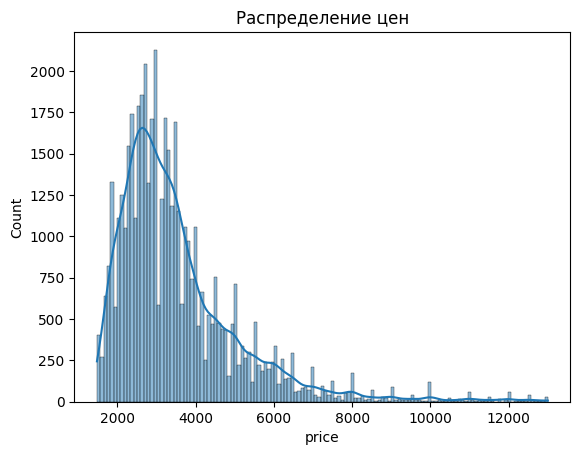

In [147]:

# Посмотрим на распределение цены
sns.histplot(y, kde=True)
plt.title('Распределение цен')
plt.show()

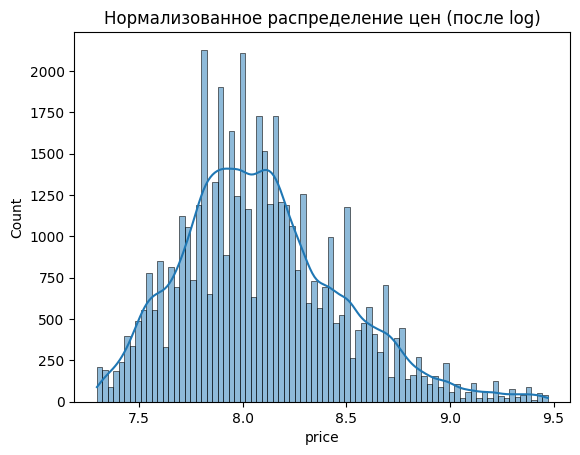

In [148]:
# Применим логарифмическую трансформацию
y_log = np.log(y)

# Постройте новый график для сравнения
sns.histplot(y_log, kde=True)
plt.title('Нормализованное распределение цен (после log)')
plt.show()

## Теперь целевая переменная выглядит более симметричной и удобной для моделирования.

In [151]:
# Прологарифмируем цену
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# Создаем словарь моделей
models = {
    'Linear Regression log': LinearRegression(),
    'Ridge Regression log': Ridge(alpha=1),
    'Lasso Regression log': Lasso(alpha=0.01),
    'ElasticNet log': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

# Обучение и оценка
results_log = []  # Хранит результаты после логарифмического преобразования

for name, model in models.items():
    # Обучаем модель на логарифмических данных
    model.fit(X_train, y_train_log)
    
    # Предсказываем на логарифмических данных
    y_pred_train_log = model.predict(X_train)
    y_pred_test_log = model.predict(X_test)
    
    # Обратное преобразование (возвращаемся к исходным ценам)
    y_pred_train = np.exp(y_pred_train_log)
    y_pred_test = np.exp(y_pred_test_log)
    
    # Оцениваем метрики
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train = r2_score(y_train, y_pred_train)
    
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)
    
    # Сохраняем результаты
    results_log.append({
        'model': name,
        'train_MAE': f"{mae_train:.2f}",
        'test_MAE': f"{mae_test:.2f}",
        'train_RMSE': f"{rmse_train:.2f}",
        'test_RMSE': f"{rmse_test:.2f}",
        'train_R2': f"{r2_train:.2f}",
        'test_R2': f"{r2_test:.2f}"
    })


In [152]:
# Переводим результаты в DataFrame
result_df_log = pd.DataFrame(results_log)

# Выведем результаты
print("\n СРАВНЕНИЕ РЕЗУЛЬТАТОВ ПОСЛЕ ЛОГАРИФМИЧЕСКОГО ПРЕОБРАЗОВАНИЯ:")

# Объединяем с удалением повторяющихся строк
union_result = pd.concat([result_df_log, final_report])

display(union_result)


 СРАВНЕНИЕ РЕЗУЛЬТАТОВ ПОСЛЕ ЛОГАРИФМИЧЕСКОГО ПРЕОБРАЗОВАНИЯ:


,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,Linear Regression log,778.90,773.39,1222.70,1137.31,0.41,0.49
1,Ridge Regression log,778.90,773.39,1222.62,1137.31,0.41,0.49
2,Lasso Regression log,782.97,774.27,1186.71,1141.27,0.45,0.49
3,ElasticNet log,780.85,773.06,1191.99,1138.01,0.44,0.49
0,Standard LinearRegression,715.83,710.43,1040.17,1027.85,0.58,0.58
1,Ridge (biblioteka),715.83,710.43,1040.17,1027.85,0.58,0.58
2,Lasso (biblioteka),715.39,709.99,1040.36,1027.79,0.58,0.58
3,ElasticNet (biblioteka),719.92,711.24,1053.81,1038.7,0.57,0.58
4,My LinearRegression,715.85,709.78,1040.99,1027.93,0.58,0.58
5,My Ridge,721.13,712.11,1064.79,1046.89,0.56,0.57


## Угол линии линейной регрессии сильно зависит от выбросов. И часто эти точки следует удалять только из обучающих данных.

## При обучении моделей мы стремимся создать обобщенную модель, которая хорошо предсказывает новые данные. Если выбросы присутствуют в обучающем наборе, они могут исказить коэффициенты модели и привести к плохой производительности на тестовых данных. Однако, выбросы также могут присутствовать в реальных данных, и наша модель должна уметь справляться с ними адекватно.

## Удаляя выбросы исключительно из обучающего набора, мы достигаем двух целей:

## - Минимизация влияния аномалий: Обучающая выборка становится более чистой, позволяя модели лучше выявить основные закономерности.
## - Проверка устойчивости модели: Оставляя выбросы в тестовом наборе, мы можем оценить, насколько модель устойчива к подобным редким случаям.

In [153]:
data_filtered_train = data[feature_list].copy()

# Оригинальные данные
X = data_filtered_train.drop('price', axis=1)  # Признаки
y = data_filtered_train['price']               # Целевая переменная

# Первый этап: полное разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# Второй этап: очищаем ТОЛЬКО обучающую выборку
q99 = y_train.quantile(0.99)
q01 = y_train.quantile(0.01)

# Применяем фильтр к обучающей выборке
mask = (y_train >= q01) & (y_train <= q99)
X_train_cleaned = X_train.loc[mask]
y_train_cleaned = y_train.loc[mask]

# Важный шаг: сбрасываем индексы для чистоты дальнейшей работы
X_train_cleaned.reset_index(drop=True, inplace=True)
y_train_cleaned.reset_index(drop=True, inplace=True)

# Контролируемый вывод
print(f'Размер очищенной обучающей выборки: {len(X_train_cleaned)}')
print(f'Размер тестовой выборки: {len(X_test)}')

Размер очищенной обучающей выборки: 38695
Размер тестовой выборки: 9871


In [154]:
# Обучение собственной модели
my_lr = MyLinearRegression()
my_lr.fit(X_train_cleaned, y_train_cleaned)
my_train_preds = my_lr.predict(X_train_cleaned)
my_test_preds = my_lr.predict(X_test)

# Составляем отчет по собственной модели
row_custom = make_row("My Linear Regression", y_train_cleaned, my_train_preds, y_test, my_test_preds)

# ----- Библиотечная реализация -----
sklearn_lr = LinearRegression()
sklearn_lr.fit(X_train_cleaned, y_train_cleaned)
sklearn_train_preds = sklearn_lr.predict(X_train_cleaned)
sklearn_test_preds = sklearn_lr.predict(X_test)

# Составляем отчет по библиотечной модели
row_sklearn = make_row("Scikit-Learn Linear Regression", y_train_cleaned, sklearn_train_preds, y_test, sklearn_test_preds)

# Объединяем отчёты в единый DataFrame
report_2 = pd.DataFrame([row_custom, row_sklearn])

# Отображаем отчёт
display(report_2)

display(report)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,My Linear Regression,713.44,818.81,1038.10,2154.91,0.58,0.35
1,Scikit-Learn Linear Regression,713.29,818.95,1037.22,2149.49,0.58,0.35


,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,My Linear Regression,715.85,709.79,1041.00,1027.94,0.58,0.58
1,Scikit-Learn Linear Regression,715.83,710.43,1040.17,1027.85,0.58,0.58


## Реализация алгоритма линейной регрессии с аналитическим решением, пакетным и мини-пакетным обучением.

In [163]:
class MiniBatchLinReg:
    def __init__(self, batch_size=100, learning_rate=0.01, n_epochs=1000):
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.coef_ = None
    
    def fit(self, X, y):
        y = np.array(y)
        m, n = X.shape
        X_b = np.c_[np.ones((m, 1)), X]  # Добавляем столбец единиц для смещения
        theta = np.zeros(n + 1)  # Начальные веса установлены в ноль
        
        num_batches = int(np.ceil(m / self.batch_size))  # Число партий
        
        for _ in range(self.n_epochs):  # Эпохи
            indices = np.arange(m)
            np.random.shuffle(indices)  # Случайное перемешивание
            
            for i in range(num_batches):
                start_idx = i * self.batch_size
                end_idx = min((i + 1) * self.batch_size, m)
                batch_indices = indices[start_idx:end_idx]
                
                Xi_batch = X_b[batch_indices]
                Yi_batch = y[batch_indices]
                
                gradient = 2 / len(Yi_batch) * Xi_batch.T.dot(Xi_batch.dot(theta) - Yi_batch)
                theta -= self.learning_rate * gradient
        
        self.coef_ = theta
    
    def predict(self, X):
        if self.coef_ is None:
            raise ValueError("Модель должна быть предварительно обучена")
        m = X.shape[0]
        X_b = np.c_[np.ones((m, 1)), X]
        return X_b.dot(self.coef_)

In [168]:
models = [
    ("LinearRegressionAnalytic", LinearRegressionAnalytic()),
    ("LinearRegressionGradientDescent", LinearRegressionGradientDescent()),
    ("MiniBatchLinReg", MiniBatchLinReg())
]

rows = []
for model_name, model in models:
    model.fit(X_train_cleaned, y_train_cleaned)
    train_preds = model.predict(X_train_cleaned)
    test_preds = model.predict(X_test)
    rows.append(make_row(model_name, y_train_cleaned, train_preds, y_test, test_preds))

report = pd.DataFrame(rows)
display(report)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2
0,LinearRegressionAnalytic,713.29,818.95,1037.22,2149.49,0.58,0.35
1,LinearRegressionGradientDescent,714.95,820.51,1043.35,2167.73,0.57,0.34
2,MiniBatchLinReg,715.78,821.17,1037.42,2148.30,0.58,0.35
